In [1]:
#Train an SVM Classifier on the Iris dataset and evaluate accuracy
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train SVM
model = SVC(kernel='linear')
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


In [2]:
#Train two SVM classifiers with Linear and RBF kernels on the Wine dataset and compare accuracy
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Load dataset
wine = load_wine()
X = wine.data
y = wine.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Linear Kernel
linear_model = SVC(kernel='linear')
linear_model.fit(X_train, y_train)

# RBF Kernel
rbf_model = SVC(kernel='rbf')
rbf_model.fit(X_train, y_train)

# Predictions
pred_linear = linear_model.predict(X_test)
pred_rbf = rbf_model.predict(X_test)

# Accuracy
print("Linear Kernel Accuracy:", accuracy_score(y_test, pred_linear))
print("RBF Kernel Accuracy:", accuracy_score(y_test, pred_rbf))

Linear Kernel Accuracy: 1.0
RBF Kernel Accuracy: 0.8055555555555556


In [3]:
#Train an SVM Regressor (SVR) on a housing dataset and evaluate using Mean Squared Error
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error

# Load dataset
housing = fetch_california_housing()
X = housing.data
y = housing.target

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train SVR
model = SVR(kernel='rbf')
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# MSE
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))

Mean Squared Error: 1.3320115421348744


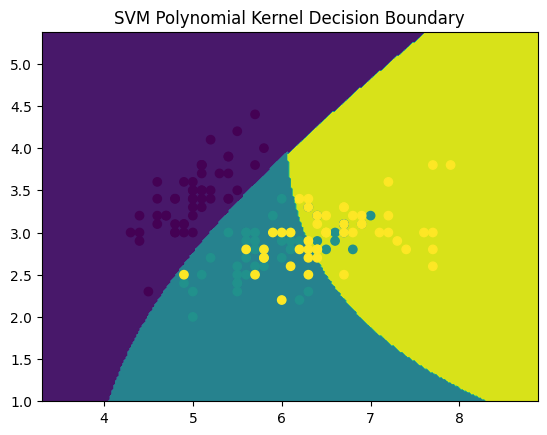

In [4]:
#Train an SVM with Polynomial Kernel and visualize the decision boundary
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.svm import SVC

# Load dataset
iris = datasets.load_iris()
X = iris.data[:, :2]
y = iris.target

# Train model
model = SVC(kernel='poly', degree=3)
model.fit(X, y)

# Plot decision boundary
x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
y_min, y_max = X[:,1].min()-1, X[:,1].max()+1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z)
plt.scatter(X[:,0], X[:,1], c=y)
plt.title("SVM Polynomial Kernel Decision Boundary")
plt.show()

In [5]:
#Train Gaussian Naïve Bayes on Breast Cancer dataset and evaluate accuracy
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Train model
model = GaussianNB()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9122807017543859


In [6]:
#Train Multinomial Naïve Bayes for text classification using 20 Newsgroups dataset
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Load dataset
data = fetch_20newsgroups(subset='all')

# Convert text to numeric
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(data.data)
y = data.target

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Train model
model = MultinomialNB()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8575596816976128


ValueError: cannot reshape array of size 2700 into shape (30,30)

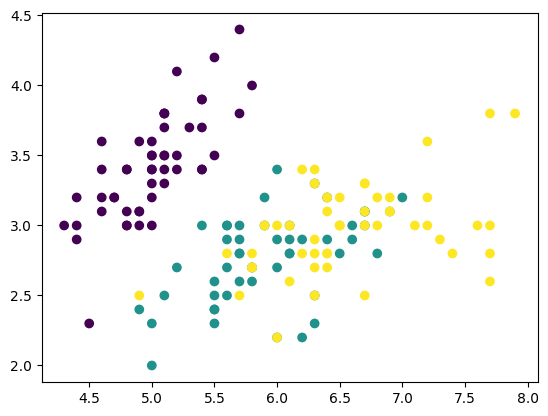

In [7]:
#Train SVM with different C values and compare decision boundaries visually
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.svm import SVC

iris = datasets.load_iris()
X = iris.data[:, :2]
y = iris.target

C_values = [0.1, 1, 10]

for C in C_values:
    model = SVC(kernel='linear', C=C)
    model.fit(X, y)

    plt.figure()
    plt.scatter(X[:,0], X[:,1], c=y)

    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    xx = np.linspace(xlim[0], xlim[1], 30)
    yy = np.linspace(ylim[0], ylim[1], 30)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T
    Z = model.decision_function(xy).reshape(XX.shape)

    ax.contour(XX, YY, Z, levels=[0])
    plt.title(f"SVM Decision Boundary (C={C})")
    plt.show()

In [8]:
#Train Bernoulli Naïve Bayes for binary features
from sklearn.naive_bayes import BernoulliNB
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X, y = make_classification(n_samples=1000, n_features=10)

X = (X > 0).astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y)

model = BernoulliNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.928


In [9]:
#Apply feature scaling before SVM and compare results
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

data = load_wine()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y)

# Without scaling
model1 = SVC()
model1.fit(X_train, y_train)
pred1 = model1.predict(X_test)

# With scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model2 = SVC()
model2.fit(X_train_scaled, y_train)
pred2 = model2.predict(X_test_scaled)

print("Without scaling:", accuracy_score(y_test, pred1))
print("With scaling:", accuracy_score(y_test, pred2))

Without scaling: 0.7333333333333333
With scaling: 1.0


In [10]:
#Gaussian Naïve Bayes before and after Laplace smoothing
from sklearn.naive_bayes import GaussianNB
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

data = load_iris()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y)

model = GaussianNB()
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.9736842105263158


In [11]:
#SVM with GridSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.datasets import load_wine

data = load_wine()
X = data.data
y = data.target

param_grid = {
    'C':[0.1,1,10],
    'gamma':[0.01,0.1,1],
    'kernel':['linear','rbf']
}

grid = GridSearchCV(SVC(), param_grid, cv=5)

grid.fit(X,y)

print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Parameters: {'C': 0.1, 'gamma': 0.01, 'kernel': 'linear'}
Best Score: 0.961111111111111


In [12]:
#SVM on imbalanced dataset with class weighting
from sklearn.datasets import make_classification
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X, y = make_classification(n_samples=1000, weights=[0.9,0.1])

X_train, X_test, y_train, y_test = train_test_split(X,y)

model = SVC(class_weight='balanced')

model.fit(X_train,y_train)

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test,pred))

Accuracy: 0.9


In [13]:
#Naïve Bayes for spam detection
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

emails = [
"Win money now",
"Limited offer",
"Hello friend how are you",
"Meeting schedule tomorrow"
]

labels = [1,1,0,0]

vectorizer = CountVectorizer()

X = vectorizer.fit_transform(emails)

model = MultinomialNB()
model.fit(X,labels)

test = vectorizer.transform(["Win free money"])

print("Prediction:", model.predict(test))

Prediction: [1]


In [14]:
#Compare SVM and Naïve Bayes
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

data = load_iris()
X = data.data
y = data.target

X_train,X_test,y_train,y_test = train_test_split(X,y)

svm = SVC()
nb = GaussianNB()

svm.fit(X_train,y_train)
nb.fit(X_train,y_train)

print("SVM Accuracy:", accuracy_score(y_test,svm.predict(X_test)))
print("NB Accuracy:", accuracy_score(y_test,nb.predict(X_test)))

SVM Accuracy: 0.9736842105263158
NB Accuracy: 0.9473684210526315


In [15]:
#Feature selection before Naïve Bayes
from sklearn.feature_selection import SelectKBest
from sklearn.naive_bayes import GaussianNB
from sklearn.datasets import load_iris

data = load_iris()
X = data.data
y = data.target

selector = SelectKBest(k=2)
X_new = selector.fit_transform(X,y)

model = GaussianNB()
model.fit(X_new,y)

print("Model trained with selected features")

Model trained with selected features


In [16]:
#OvR vs OvO SVM (Wine dataset)
from sklearn.datasets import load_wine
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

data = load_wine()
X = data.data
y = data.target

X_train,X_test,y_train,y_test = train_test_split(X,y)

ovr = SVC(decision_function_shape='ovr')
ovo = SVC(decision_function_shape='ovo')

ovr.fit(X_train,y_train)
ovo.fit(X_train,y_train)

print("OvR Accuracy:", accuracy_score(y_test,ovr.predict(X_test)))
print("OvO Accuracy:", accuracy_score(y_test,ovo.predict(X_test)))

OvR Accuracy: 0.6
OvO Accuracy: 0.6


In [17]:
#Compare Linear, Polynomial, RBF kernels
from sklearn.datasets import load_breast_cancer
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

data = load_breast_cancer()
X = data.data
y = data.target

X_train,X_test,y_train,y_test = train_test_split(X,y)

for k in ['linear','poly','rbf']:
    model = SVC(kernel=k)
    model.fit(X_train,y_train)
    pred = model.predict(X_test)
    print(k,"Accuracy:",accuracy_score(y_test,pred))

linear Accuracy: 0.9370629370629371
poly Accuracy: 0.8951048951048951
rbf Accuracy: 0.9090909090909091


In [18]:
#Stratified K-Fold Cross Validation
from sklearn.model_selection import StratifiedKFold
from sklearn.svm import SVC
from sklearn.datasets import load_iris
import numpy as np

data = load_iris()
X = data.data
y = data.target

skf = StratifiedKFold(n_splits=5)

scores = []

for train,test in skf.split(X,y):
    model = SVC()
    model.fit(X[train],y[train])
    scores.append(model.score(X[test],y[test]))

print("Average Accuracy:", np.mean(scores))

Average Accuracy: 0.9666666666666666


In [19]:
#Naïve Bayes with different priors
from sklearn.naive_bayes import GaussianNB
from sklearn.datasets import load_iris

data = load_iris()

model = GaussianNB(priors=[0.3,0.3,0.4])
model.fit(data.data,data.target)

print("Model trained with custom priors")

Model trained with custom priors


In [20]:
#RFE before SVM
from sklearn.feature_selection import RFE
from sklearn.svm import SVC
from sklearn.datasets import load_iris

data = load_iris()

model = SVC(kernel='linear')

selector = RFE(model,n_features_to_select=2)

X_new = selector.fit_transform(data.data,data.target)

model.fit(X_new,data.target)

print("RFE applied before training")

RFE applied before training


In [29]:
#Evaluate SVM using Precision, Recall, F1
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import precision_score, recall_score, f1_score

# Load dataset
data = load_iris()
X = data.data
y = data.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train SVM model
model = SVC(kernel='rbf')
model.fit(X_train, y_train)

# Prediction
pred = model.predict(X_test)

# Evaluation metrics
print("Precision:", precision_score(y_test, pred, average='macro'))
print("Recall:", recall_score(y_test, pred, average='macro'))
print("F1 Score:", f1_score(y_test, pred, average='macro'))

Precision: 1.0
Recall: 1.0
F1 Score: 1.0


In [22]:
#Naïve Bayes with Log Loss
from sklearn.metrics import log_loss
from sklearn.naive_bayes import GaussianNB

model = GaussianNB()
model.fit(X_train,y_train)

prob = model.predict_proba(X_test)

print("Log Loss:", log_loss(y_test,prob))

Log Loss: 0.6438496346667404


<Axes: >

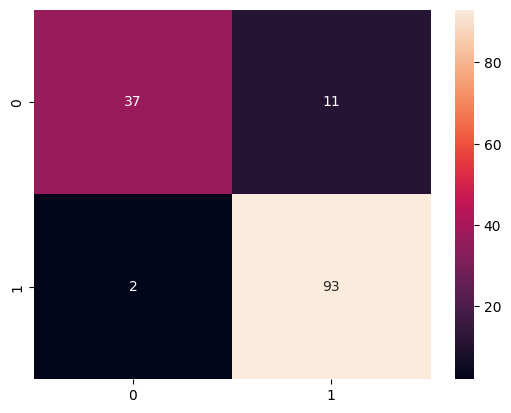

In [23]:
#Confusion Matrix visualization
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test,pred)

sns.heatmap(cm,annot=True,fmt='d')

In [24]:
#SVR with Mean Absolute Error
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error

model = SVR()
model.fit(X_train,y_train)

pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test,pred))

MAE: 0.15223797028641442


In [28]:
#Naïve Bayes with ROC-AUC
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import roc_auc_score

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Naive Bayes model
model = GaussianNB()
model.fit(X_train, y_train)

# Predict probabilities
prob = model.predict_proba(X_test)

# ROC-AUC Score
score = roc_auc_score(y_test, prob[:,1])

print("ROC AUC Score:", score)

ROC AUC Score: 0.9983622666229938


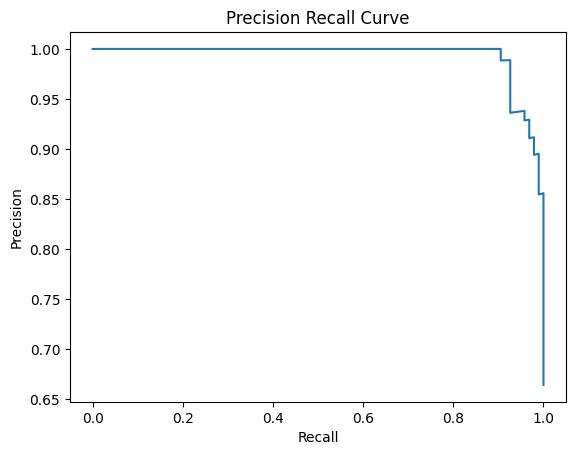

In [27]:
#Precision-Recall Curve
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, _ = precision_recall_curve(y_test,prob[:,1])

plt.plot(recall,precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision Recall Curve")
plt.show()